# GRUAN evaluation dataset

The GRUAN evaluation dataset included in ContrailBench provides a gridded dataset of PCR observations based on [GRUAN](https://www.gruan.org) radiosonde measurements. This dataset is used to calculate forecast hit rates in ContrailBench benchmarks.

The GRUAN evaluation dataset is available alongside other evaluation datasets in a public cloud bucket (`gs://contrailbench-public-data`). This notebook shows
1. How to load GRUAN evaluation data using Pandas
2. How to interpret the contents of the GRUAN evaluation dataset
3. How to use the GRUAN evaluation dataset to compute ContrailBench hit rate metrics

In [1]:
import datetime
import os

import aiohttp
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

## Loading GRUAN evaluation data

GRUAN evaluation data is sharded by time (one file per hour) and altitude (one file per flight level). Coverage for each ContrailBench release cycle is as follows:

| Release | Times | Altitudes| GCS path |
| --- | --- | --- | --- |
| 2026 Q1 | Jan-Dec 2024 | FL270-440 | `gs://contrail-bench-public-data/2026Q1/gruan` |

Because gridded GRUAN data is relatively sparse, the dataset is stored as parquet files with one row for each grid cell with non-zero flight distance. These files can be read directly from GCS with Pandas.

> **Warning**: be very careful about timezone-naive datetimes when using ContrailBench evaluation datasets. Python's datetime module [assumes that naive datetimes represent local time](https://docs.python.org/3/library/datetime.html#datetime.datetime.timestamp), which affects the POSIX timestamp returned by `datetime.timestamp()`.

In [2]:
gcs_path = "gs://contrailbench-public-data/2026Q1/gruan"
time = datetime.datetime(2024, 6, 1, 0, tzinfo=datetime.UTC)
flight_level = 350

df = pd.read_parquet(f"{gcs_path}/{int(time.timestamp())}_{flight_level}.pq")
df

,latitude,longitude,pcr_count,total_count
0,22.50,114.25,0,27
1,46.75,7.00,0,43
2,52.00,5.00,9,33
3,67.50,27.25,0,29


## Interpretation

Rows of the dataset provide counts of individual GRUAN measurements aggregated on a spatiotemporal grid with 0.25 degree horizontal resolution. Horizontal bounds are from -180 degrees to 179.75 degrees longitude and -80 degrees to 80 degrees latitude. Each grid cell includes measurements made

1. within 0.125 degrees latitude and longitude of the provided latitude and longitude coordinates,
2. within 250 vertical ft of the target flight level, and
3. within 30 minutes of the target time

The `pcr_count` column provides the number of GRUAN measurements inside PCRs, as determined by measured temperature and humidity. The `total_count` column provides the total number of GRUAN measurements, both within and outside PCRs.

Grid cells without any GRUAN measurements are omitted from the dataset to reduce data volume. Because GRUAN radiosondes collect measurements along vertical profiles, measurements are extremely horizontally sparse and many of the parquet files in the evaluation dataset contain zero rows. If necessary, omitted grid cells can be restored using xarray:

In [3]:
all_lons = np.arange(-180.0, 180.0, 0.25)
all_lats = np.arange(-80, 80.25, 0.25)
ds = df.set_index(["longitude", "latitude"]).to_xarray().fillna(0.0)
ds = ds.reindex(longitude=all_lons, latitude=all_lats, fill_value=0.0)
ds

<xarray.Dataset> Size: 15MB
Dimensions:      (longitude: 1440, latitude: 641)
Coordinates:
  * longitude    (longitude) float64 12kB -180.0 -179.8 -179.5 ... 179.5 179.8
  * latitude     (latitude) float64 5kB -80.0 -79.75 -79.5 ... 79.5 79.75 80.0
Data variables:
    pcr_count    (longitude, latitude) float64 7MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    total_count  (longitude, latitude) float64 7MB 0.0 0.0 0.0 ... 0.0 0.0 0.0

Because of the extreme sparsity, using the original dataframe often produces more effective visualizations:

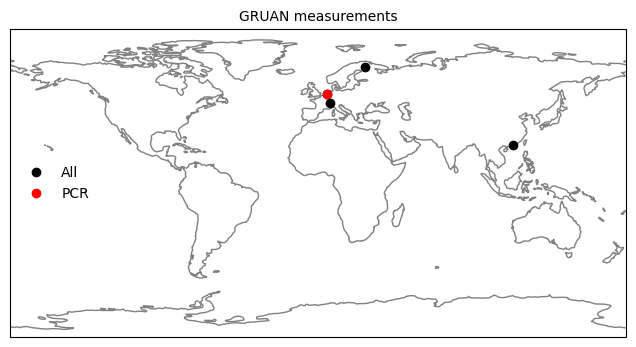

In [11]:
plt.figure(figsize=(12, 4))
ax = plt.subplot(111, projection=ccrs.PlateCarree())
ax.plot(df["longitude"], df["latitude"], "ko", label="All", transform=ccrs.PlateCarree())
ax.plot(
    df["longitude"].where(df["pcr_count"] > 0),
    df["latitude"].where(df["pcr_count"] > 0),
    "ro",
    label="PCR",
    transform=ccrs.PlateCarree(),
)
ax.coastlines(color="gray")
ax.set_global()
ax.set_title("GRUAN measurements", fontsize=10)
ax.legend(loc="center left", frameon=False)

## Use in ContrailBench metrics

The GRUAN evaluation dataset is used in PCR benchmarks to calculate forecast hit rates, a proxy for the effectiveness of avoidance.

This notebook uses the Contrails.org forecast for an example calculation. See the [Contrails.org example notebook](contrails-org.ipynb) for details about accessing and preprocessing the Contrails.org forecast.

In [12]:
url = "https://api.contrails.org/v1/grids"
params = {
    "aircraft_class": "default",
    "flight_level": str(flight_level),
    "time": time.strftime("%Y-%m-%dT%H"),
    "units": "ef_per_m",
}
headers = {"x-api-key": os.environ["CONTRAILS_API_KEY"]}

async with (
    aiohttp.ClientSession(raise_for_status=True) as session,
    session.get(url, params=params, headers=headers) as resp,
):
    content = await resp.read()

with open("forecast.nc", "wb") as f:
    f.write(content)
ds = xr.open_dataset("forecast.nc")

ds["pcr"] = ds["ef_per_m"] != 0
processed = ds[["pcr"]]

Forecast hit rates can be calculated using some xarray indexing tricks. This notebook computes hit rates treating all grid cells with non-zero `pcr_count` as observed PCRs and weighting grid cells by area, consistent with ContrailBench benchmarks.

In [13]:
target_lon = xr.DataArray(df["longitude"].loc[df["pcr_count"] > 0], dims="row")
target_lat = xr.DataArray(df["latitude"].loc[df["pcr_count"] > 0], dims="row")
area = xr.DataArray(np.cos(np.deg2rad(df["latitude"].loc[df["pcr_count"] > 0])), dims="observation")

pcr = processed["pcr"].sel(longitude=target_lon, latitude=target_lat)
fcst_area = area.where(pcr).sum().item()
tot_area = area.sum().item()

print(f"Forecast hit rate: {fcst_area / tot_area:.3f}")

Forecast hit rate: 0.000
